Project Overview

This project uses a sample student's performance dataset downloaded from Kaggle (https://www.kaggle.com/code/lalit7881/student-exam-performance-dataset-analysis-eda/input). The primary objective is to perform an exploratory data analysis (EDA) to understand the structure and meaning of the dataset.

The analysis focuses on:

- Exploring the dataset to identify key variables and patterns
- Cleaning and preparing the data for analysis
- Conducting descriptive and exploratory analysis to extract insights

The goal is to gain a clear understanding of the dataset and uncover meaningful information that can support further analysis and answer to the question: What factors influence students' exam scores, and how can we make a positive impact on them?

## Loading data and importing the necessary library

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv('/Users/Admin/Desktop/my_analyst_projects/student_performance/StudentPerformanceFactors.csv')

## Data overview

In [34]:
df.shape

(6607, 20)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [36]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Data cleaning

In [37]:
#rename columns
df.columns = df.columns.str.lower().str.strip()

In [38]:
#check null value
df.isnull().sum()

hours_studied                  0
attendance                     0
parental_involvement           0
access_to_resources            0
extracurricular_activities     0
sleep_hours                    0
previous_scores                0
motivation_level               0
internet_access                0
tutoring_sessions              0
family_income                  0
teacher_quality               78
school_type                    0
peer_influence                 0
physical_activity              0
learning_disabilities          0
parental_education_level      90
distance_from_home            67
gender                         0
exam_score                     0
dtype: int64

In [39]:
print((90+78+67)/6607*100)

3.5568336612683513


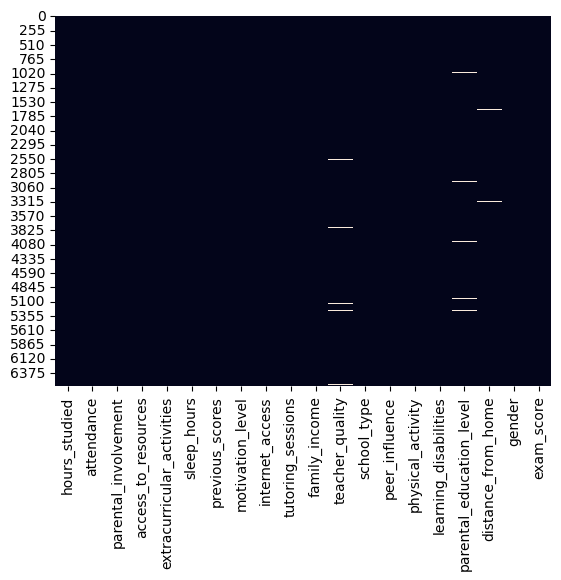

In [40]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [41]:
# Because of low missing value (around 3.5%) and randomness of its distribution, I decided to drop the NA values in the dataset, and set it as the df_cleaned to continue cleaning
df_cleaned = df.dropna()

In [42]:
#check null value
df_cleaned.isnull().sum()

hours_studied                 0
attendance                    0
parental_involvement          0
access_to_resources           0
extracurricular_activities    0
sleep_hours                   0
previous_scores               0
motivation_level              0
internet_access               0
tutoring_sessions             0
family_income                 0
teacher_quality               0
school_type                   0
peer_influence                0
physical_activity             0
learning_disabilities         0
parental_education_level      0
distance_from_home            0
gender                        0
exam_score                    0
dtype: int64

In [43]:
for col in df_cleaned.columns:
    print(f"Column: {col}")
    print(f"Unique count: {df_cleaned[col].nunique()}")
    print(df_cleaned[col].value_counts().head())
    print("-"*30)

Column: hours_studied
Unique count: 41
hours_studied
20    448
19    425
21    420
18    393
23    389
Name: count, dtype: int64
------------------------------
Column: attendance
Unique count: 41
attendance
67    182
76    179
98    178
77    177
64    176
Name: count, dtype: int64
------------------------------
Column: parental_involvement
Unique count: 3
parental_involvement
Medium    3251
High      1836
Low       1291
Name: count, dtype: int64
------------------------------
Column: access_to_resources
Unique count: 3
access_to_resources
Medium    3204
High      1900
Low       1274
Name: count, dtype: int64
------------------------------
Column: extracurricular_activities
Unique count: 2
extracurricular_activities
Yes    3807
No     2571
Name: count, dtype: int64
------------------------------
Column: sleep_hours
Unique count: 7
sleep_hours
7    1682
8    1354
6    1322
9     753
5     668
Name: count, dtype: int64
------------------------------
Column: previous_scores
Unique count: 

In [44]:
# turn gender into 0 if Male and 1 if Female
df_cleaned.loc[:, 'gender'] = df_cleaned['gender'].map({"Male": 0, "Female":1})

In [45]:
# turn school_type into 0 if Private and 1 if Public
df_cleaned.loc[:, 'school_type'] = df_cleaned['school_type'].map({"Private": 0, "Public":1})

In [46]:
#Encoding for extracurricular_activities,internet_access,learning_disabilities
mapping = {
    "No": 0,
    "Yes": 1
}
cols = [
    "extracurricular_activities",
    "internet_access",
    "learning_disabilities"
]

for col in cols:
    df_cleaned.loc[:, col] = df_cleaned[col].map(mapping)

In [47]:
#rename column 'gender', 'school_type', extracurricular_activities,internet_access,learning_disabilities
df_cleaned.rename(columns={
    'gender': 'is_female',
    'school_type': 'is_public',
    'extracurricular_activities': 'having_extracurricular_activities',
    'internet_access': 'having_internet_access',
    'learning_disabilities': 'having_learning_disabilities'}, inplace = True)

/var/folders/s1/pp6vc2js40qbg7b1xs2dq1jc0000gn/T/ipykernel_27659/1289706410.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned.rename(columns={


In [48]:
#Encoding for parental_involvement, access_to_resources, motivation_level, family_income, teacher_quality
mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}
cols = [
    "parental_involvement",
    "access_to_resources",
    "motivation_level",
    "family_income",
    "teacher_quality"
]

for col in cols:
    df_cleaned.loc[:, col] = df_cleaned[col].map(mapping)

In [49]:
#Encoding for peer_influence
df_cleaned.loc[:, 'peer_influence'] = df_cleaned['peer_influence'].map({"Negative": -1, "Neutral": 0, "Positive": 1})

In [50]:
#Encoding for peer_influence
df_cleaned.loc[:, 'parental_education_level'] = df_cleaned['parental_education_level'].map({"High School": 0, "College": 1, "Postgraduate": 2})

In [51]:
#Encoding for distance_from_home
df_cleaned.loc[:, 'distance_from_home'] = df_cleaned['distance_from_home'].map({"Near": 0, "Moderate": 1, "Far": 2})

In [52]:
df_cleaned["peer_influence"].value_counts()

peer_influence
1     2553
0     2495
-1    1330
Name: count, dtype: int64

In [59]:
df_cleaned.info()
df_cleaned.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 6378 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   hours_studied                      6378 non-null   int64 
 1   attendance                         6378 non-null   int64 
 2   parental_involvement               6378 non-null   object
 3   access_to_resources                6378 non-null   object
 4   having_extracurricular_activities  6378 non-null   object
 5   sleep_hours                        6378 non-null   int64 
 6   previous_scores                    6378 non-null   int64 
 7   motivation_level                   6378 non-null   object
 8   having_internet_access             6378 non-null   object
 9   tutoring_sessions                  6378 non-null   int64 
 10  family_income                      6378 non-null   object
 11  teacher_quality                    6378 non-null   object
 12  is_public  

hours_studied                        0
attendance                           0
parental_involvement                 0
access_to_resources                  0
having_extracurricular_activities    0
sleep_hours                          0
previous_scores                      0
motivation_level                     0
having_internet_access               0
tutoring_sessions                    0
family_income                        0
teacher_quality                      0
is_public                            0
peer_influence                       0
physical_activity                    0
having_learning_disabilities         0
parental_education_level             0
distance_from_home                   0
is_female                            0
exam_score                           0
dtype: int64